In [2]:
import pandas as pd

dataset = pd.read_csv(r"C:\Users\hp\PycharmProjects\PythonProject\adsbModel\aircraft-data_nov_dec.csv")
print(dataset.head())
print(dataset.describe())
print(dataset.columns)

    flight tail_number     long      lat    alt      manufacturer  \
0   SIS300      N300NJ -118.213  34.5823  20175    BOMBARDIER INC   
1  UAL1434      N67501 -117.937  34.6038  36700            BOEING   
2  SWA3287      N483WN -118.035  34.6345  13225            BOEING   
3  AAL2059      N660AW -118.075  34.4643  33750  AIRBUS INDUSTRIE   
4    N84PJ       N84PJ -117.756  34.6002  34725          DASSAULT   

           model reg_expiration              reg_owner     reg_city  \
0    BD-100-1A10        1/31/24   PUNTA PACIFICO I LLC  BAKERSFIELD   
1          737-9        4/30/24    UNITED AIRLINES INC      CHICAGO   
2        737-7H4        8/31/24  SOUTHWEST AIRLINES CO       DALLAS   
3       A320-232        2/29/24     US BANK NA TRUSTEE       BOSTON   
4  FALCON 2000EX       12/31/24    HAMPTON AIRWAYS INC  SELLERSBURG   

       reg_state  squawk  mph        spotted  
0     CALIFORNIA  1077.0  474  11/7/22 13:30  
1       ILLINOIS  7730.0  523  11/7/22 13:30  
2          TEXAS 

In [3]:
'''
Yeni öznitelikler
Feature Engineering
'''
dataset=dataset.sort_values(['tail_number','spotted'])
dataset['alt_diff']=dataset.groupby('tail_number')['alt'].diff()
dataset['alt_diff']=dataset['alt_diff'].fillna(0)
dataset['speed_diff']=dataset.groupby('tail_number')['mph'].diff()
dataset['spotted'] = pd.to_datetime(dataset['spotted'], format='%m/%d/%y %H:%M')
dataset['time_diff_sec']=dataset.groupby('tail_number')['spotted'].diff().dt.total_seconds()
dataset['vertical_rate']=dataset['alt_diff']/dataset['time_diff_sec']
dataset['acceleration']=dataset['speed_diff']/dataset['time_diff_sec']
dataset['speed_zscore']=dataset.groupby('model')['mph'].transform(lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0)
emergency_codes=[7500,7600,7700]
dataset['is_emergency_squawk']=dataset['squawk'].isin(emergency_codes).astype(int)
dataset['speed_diff']=dataset['speed_diff'].fillna(0)
dataset['vertical_rate']=dataset['vertical_rate'].fillna(0)
dataset['acceleration']=dataset['acceleration'].fillna(0)
dataset['speed_zscore']=dataset.groupby('model')['speed_zscore'].transform(
    lambda x: x.fillna(x.mean()))

In [4]:
drop_columns=['reg_expiration', 'reg_owner', 'reg_city', 'reg_state']
dataset=dataset.drop(drop_columns,axis=1, errors='ignore')
dataset['vertical_rate']=dataset['vertical_rate'].fillna(0)
dataset['acceleration']=dataset['acceleration'].fillna(0)

In [5]:
from sklearn.ensemble import IsolationForest
features=['alt', 'mph', 'alt_diff', 'speed_diff', 'vertical_rate', 'acceleration','speed_zscore', 'is_emergency_squawk']
X=dataset[features]
X=X.dropna()
dataset=dataset.loc[X.index].copy()
isolation_forest=IsolationForest(
    n_estimators=200,
    max_features=1.0,
    random_state=42,
    bootstrap=False,
    max_samples='auto'
)
dataset['anomaly_score'] = isolation_forest.fit_predict(X)
dataset['is_anomaly'] = dataset['anomaly_score'].map({1: 0, -1: 1})
print(dataset['is_anomaly'].value_counts())

is_anomaly
0    28097
1     2088
Name: count, dtype: int64


In [6]:
top_planes=dataset.groupby('tail_number').size().nlargest(5)
print(top_planes)
print(dataset[dataset['tail_number'].isin(top_planes.index)]['is_anomaly'].value_counts())

tail_number
N72NG     84
N77NG     78
N266JX    75
N261JX    52
N254JX    50
dtype: int64
is_anomaly
0    217
1    122
Name: count, dtype: int64


In [7]:
suspect_planes=['N72NG', 'N77NG', 'N266JX', 'N261JX', 'N254JX']
print(dataset[dataset['tail_number'].isin(suspect_planes)][
    ['tail_number', 'alt', 'mph', 'is_emergency_squawk',
     'vertical_rate', 'acceleration', 'is_anomaly']
].sort_values('tail_number'))
print(dataset[dataset['tail_number'].isin(suspect_planes)]['is_emergency_squawk'].sum())

      tail_number    alt  mph  is_emergency_squawk  vertical_rate  \
1464       N254JX  12350  460                    0       0.000000   
18763      N254JX  10550  460                    0       0.005787   
18949      N254JX  22400  460                    0       0.637097   
19323      N254JX  21075  460                    0      -0.019895   
20041      N254JX   9100  460                    0      -0.118097   
...           ...    ...  ...                  ...            ...   
7724        N77NG   7500  219                    0       0.159314   
7581        N77NG   5875  460                    0      -0.003001   
5737        N77NG   6725  460                    0       2.645833   
11301       N77NG   7975  460                    0       0.006010   
16160       N77NG   4850  281                    0      -0.027488   

       acceleration  is_anomaly  
1464       0.000000           0  
18763      0.000000           0  
18949      0.000000           0  
19323      0.000000           0  
2

In [8]:
print(dataset[dataset['tail_number'].isin(suspect_planes)]
    .groupby('is_anomaly')['mph'].describe())
print(dataset.groupby('is_anomaly')['vertical_rate'].describe())

            count        mean         std    min    25%    50%    75%    max
is_anomaly                                                                  
0           217.0  446.520737   50.661922  207.0  460.0  460.0  460.0  460.0
1           122.0  310.090164  105.179815  175.0  221.5  265.0  460.0  460.0
              count      mean       std     min       25%       50%       75%  \
is_anomaly                                                                      
0           28097.0  0.008780  0.429430 -26.250 -0.003537  0.000000  0.004002   
1            2088.0  0.667117  3.477632 -32.875 -0.044863  0.016705  1.412760   

               max  
is_anomaly          
0            6.750  
1           59.625  


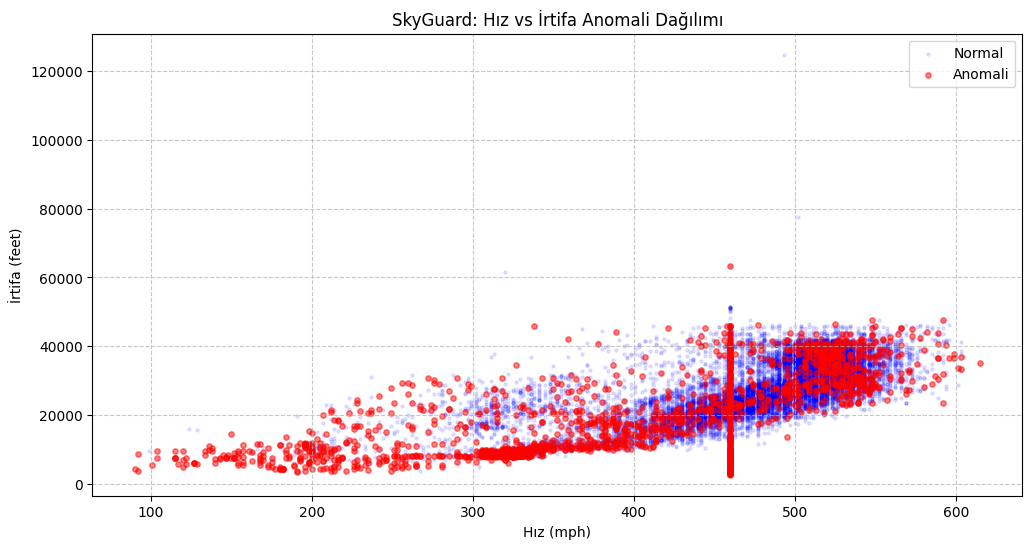

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.scatter(dataset[dataset['is_anomaly'] == 0]['mph'],
            dataset[dataset['is_anomaly'] == 0]['alt'],
            c='blue', alpha=0.1, label='Normal', s=5)
plt.scatter(dataset[dataset['is_anomaly'] == 1]['mph'],
            dataset[dataset['is_anomaly'] == 1]['alt'],
            c='red', alpha=0.5, label='Anomali', s=15)
plt.title('SkyGuard: Hız vs İrtifa Anomali Dağılımı')
plt.xlabel('Hız (mph)')
plt.ylabel('İrtifa (feet)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

<h6>Türkçe</h6>
Anomali yapan uçaklar için referans model. Askeri amaçlarla kalkan Northman Grumman firmasına
ait uçaklar ani hızlanma irtifa değişiminde anomali yapmaktadır.
<h6>İngilizce</h6>
Reference model for anomalous aircraft. Aircraft belonging to the Northman Grumman company, which are deployed for
military purposes, exhibit anomalies during sudden acceleration and altitude changes.
<h6>Almanca</h6>
Referenzmodell für anomale Flugzeuge. Flugzeuge des Unternehmens Northman Grumman, die für militärische Zwecke
eingesetzt werden, zeigen bei plötzlicher Beschleunigung und Höhenänderung Anomalien.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
df_model = dataset.copy() if 'dataset' in locals() else dataset.copy()
features = ['alt', 'mph', 'alt_diff', 'speed_diff', 'speed_zscore', 'vertical_rate', 'acceleration']
suspect_planes = ['N72NG', 'N77NG']
df_model['label'] = df_model['tail_number'].isin(suspect_planes).astype(int)
X = df_model[features].dropna()
y = df_model.loc[X.index, 'label']
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42,
stratify=y
)
rf_model = RandomForestClassifier(
n_estimators=100,
random_state=42
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6005
           1       0.87      0.62      0.73        32

    accuracy                           1.00      6037
   macro avg       0.93      0.81      0.86      6037
weighted avg       1.00      1.00      1.00      6037



In [20]:
import joblib
joblib.dump(isolation_forest, 'states_Vectors_from_Open_Sky/skyguard_anomaly_model.pkl')
print("başarılı")

başarılı


In [12]:
from keras.layers import LSTM,RepeatVector,TimeDistributed,Dense,Input
from keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
import numpy as np
scaler = MinMaxScaler()
columns_for_learning=dataset[['lat', 'alt', 'long', 'mph', 'vertical_rate', 'acceleration']]
scaledData=scaler.fit_transform(columns_for_learning)
def create_sequences(data, window_size=10):
    sequences = []
    for i in range(len(data) - window_size):
        sequences.append(data[i:i+window_size])
    return np.array(sequences)
X_lstm = create_sequences(scaledData, window_size=10)
input_shape = (X_lstm.shape[1], X_lstm.shape[2])
model = Sequential([
    Input(shape=input_shape),
    LSTM(32, activation='tanh', recurrent_activation='sigmoid', return_sequences=False),
    RepeatVector(X_lstm.shape[1]),
    LSTM(32, activation='tanh', return_sequences=True),
    TimeDistributed(Dense(X_lstm.shape[2]))
])
model.compile(optimizer='adam', loss='mae')
model.summary()

C:\Users\hp\PycharmProjects\PythonProject\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\hp\PycharmProjects\PythonProject\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\hp\PycharmProjects\PythonProject\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.pr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 6)          │           198 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,510 (52.77 KB)

 Trainable params: 13,510 (52.77 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_lstm, X_lstm,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/50
849/849 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0678 - val_loss: 0.0581
Epoch 2/50
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0568 - val_loss: 0.0565
Epoch 3/50
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0556 - val_loss: 0.0555
Epoch 4/50
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0549 - val_loss: 0.0549
Epoch 5/50
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0543 - val_loss: 0.0542
Epoch 6/50
849/849 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.0541 - val_loss: 0.0544
Epoch 7/50
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0538 - val_loss: 0.0539
Epoch 8/50
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0534 - val_loss: 0.0527
Epoch 9/50
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0519 - val_loss: 0.0518
Epoch 10/50
849/849 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0513 - val_loss: 0.0510
Epoch 11/50
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0508 - val_loss: 0.0511
Epoch 12/50
849/849 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/s

In [14]:
predictions=model.predict(X_lstm)
mae_loss=np.mean(np.abs(predictions - X_lstm), axis=(1, 2))
threshold=np.percentile(mae_loss, 95)
dataset['lstm_anomaly'] = 0
dataset.iloc[10:,dataset.columns.get_loc('lstm_anomaly')] = (mae_loss > threshold).astype(int)

943/943 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [19]:
predictions = model.predict(X_lstm)
mae_loss = np.mean(np.abs(predictions - X_lstm), axis=(1, 2))
threshold = np.percentile(mae_loss, 98)
print(f"Dinamik Anomali Eşiği: {threshold}")
print(f"dynamische Anomalieschwelle: {threshold}")

943/943 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Dinamik Anomali Eşiği: 0.040352357092334194
dynamische Anomalieschwelle: 0.040352357092334194


In [16]:
anomaly_df = pd.DataFrame(index=dataset.index[10:])
anomaly_df['loss'] = mae_loss
anomaly_df['threshold'] = 0.04068
anomaly_df['is_anomaly'] = anomaly_df['loss'] > anomaly_df['threshold']
suspects = dataset[dataset['tail_number'].isin(['N72NG', 'N77NG'])].index
suspect_anomalies = anomaly_df.loc[anomaly_df.index.intersection(suspects)]
print(f"Askeri uçaklarda tespit edilen anomali sayısı: {suspect_anomalies['is_anomaly'].sum()}")

Askeri uçaklarda tespit edilen anomali sayısı: 35


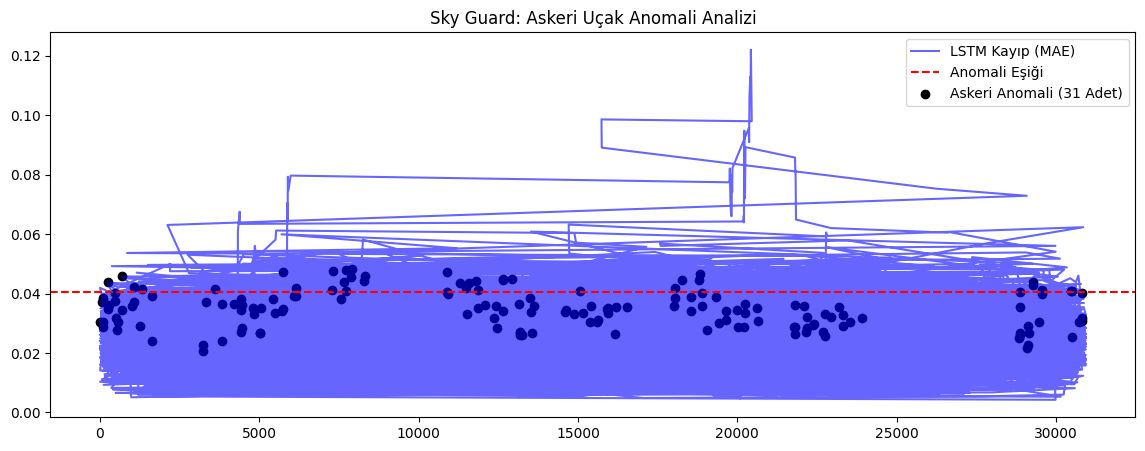

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))
plt.plot(anomaly_df['loss'], label='LSTM Kayıp (MAE)', color='blue', alpha=0.6)
plt.axhline(y=0.0406, color='red', linestyle='--', label='Anomali Eşiği')
plt.scatter(suspect_anomalies.index, suspect_anomalies['loss'], color='black', label='Askeri Anomali (31 Adet)')
plt.title('Sky Guard: Askeri Uçak Anomali Analizi')
plt.legend()
plt.show()

In [18]:
try:
    model.save('skyguard_lstm_v1.keras')
except Exception as e:
    print("hata")

In [1]:
import sqlite3

conn = sqlite3.connect('SkyGuard.db')
cursor = conn.cursor()

cursor.execute('''
    CREATE TABLE IF NOT EXISTS Users (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        username TEXT NOT NULL UNIQUE,
        password_hash TEXT NOT NULL,
        created_at DATETIME DEFAULT CURRENT_TIMESTAMP
    )
''')

conn.commit()
print("Veritabanı ve Users tablosu başarıyla oluşturuldu.")

Veritabanı ve Users tablosu başarıyla oluşturuldu.


In [ ]:
import bcrypt
def register_user(username, password):
    salt = bcrypt.gensalt()
    hashed_password = bcrypt.hashpw(password.encode("utf-8"), salt)
    try:
        cursor.execute('''
        INSERT INTO Users (username, password_hash, created_at)''')
        conn.commit()
    except sqlite3.IntegrityError:
        print("Hata!")

In [2]:
import sqlite3
import bcrypt

def setup_database_and_add_user():
    username = "Leiter"
    plain_password = "23M@rt2003" # Giriş yaparken kullanacağın şifre

    # 1. Şifreyi BCrypt ile hash'liyoruz
    salt = bcrypt.gensalt()
    hashed_password = bcrypt.hashpw(plain_password.encode('utf-8'), salt)

    # 2. Veritabanına bağlanıyoruz
    conn = sqlite3.connect('SkyGuard.db')
    cursor = conn.cursor()

    try:
        # 3. ÖNEMLİ: Eğer tablo yoksa burada sıfırdan oluşturuyoruz
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS Users (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                username TEXT NOT NULL UNIQUE,
                password_hash BLOB NOT NULL,
                created_at DATETIME DEFAULT CURRENT_TIMESTAMP
            )
        ''')
        print("Users tablosu başarıyla kontrol edildi/oluşturuldu.")

        # 4. Eğer eski (hatalı veya null) bir admin varsa temizleyelim
        cursor.execute("DELETE FROM Users WHERE username = ?", (username,))

        # 5. Yeni kullanıcımızı ekleyelim
        cursor.execute("INSERT INTO Users (username, password_hash) VALUES (?, ?)",
                       (username, hashed_password))

        conn.commit()
        print(f"Başarılı! '{username}' kullanıcısı (Şifre: {plain_password}) veritabanına eklendi.")

    except Exception as e:
        print(f"Hata oluştu: {e}")
    finally:
        conn.close()

if __name__ == "__main__":
    setup_database_and_add_user()

Users tablosu başarıyla kontrol edildi/oluşturuldu.
Başarılı! 'Leiter' kullanıcısı (Şifre: 23M@rt2003) veritabanına eklendi.
